# Statistical Demand Forecasting Baselines

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ericmavigo/retail-demand-forecasting/blob/main/notebooks/01_m5_demand_forecasting.ipynb)

**Business question:** How many units should each store expect to sell during the next 28 days?

> **Public portfolio snapshot:** All tables, metrics and charts below were generated from the official Kaggle M5 data and saved in this notebook. You can review the complete work without credentials. To reproduce the analysis, run the notebook with your own Kaggle API token; no private token is stored in this repository.

## 1. Environment and official data

In [1]:
from pathlib import Path
import sys
import subprocess

if 'google.colab' in sys.modules:
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '-q',
        'kagglehub>=1.0,<2', 'pandas>=2.2,<3', 'numpy>=2,<3',
        'matplotlib>=3.9,<4', 'scikit-learn>=1.5,<2', 'lightgbm>=4.5,<5',
    ])

import numpy as np
import pandas as pd
get_ipython().run_line_magic('matplotlib', 'inline')
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
sys.path.insert(0, str(PROJECT_ROOT))

pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {
    'navy': '#17324D',
    'blue': '#2F80ED',
    'teal': '#16A085',
    'orange': '#F2994A',
    'red': '#EB5757',
    'gray': '#667085',
}


In [2]:
import kagglehub

# Download latest version. KaggleHub automatically checks the Colab secret
# named KAGGLE_API_TOKEN. If it is missing, the login widget opens once.
try:
    path = kagglehub.competition_download('m5-forecasting-accuracy')
except Exception as error:
    if error.__class__.__name__ != 'UnauthenticatedError':
        raise
    print('Kaggle authentication is required. Paste your Kaggle API token in the login form below.')
    kagglehub.login()
    path = kagglehub.competition_download('m5-forecasting-accuracy')

print("Path to competition files:", path)

DATA_DIR = Path(path)
if not (DATA_DIR / 'calendar.csv').exists():
    DATA_DIR = next(p.parent for p in DATA_DIR.rglob('calendar.csv'))

required = {'calendar.csv', 'sell_prices.csv', 'sales_train_evaluation.csv'}
available = {p.name for p in DATA_DIR.glob('*.csv')}
assert required.issubset(available), f"Missing files: {sorted(required - available)}"


Execution source: official Kaggle M5 competition files
Required files available: ['calendar.csv', 'sales_train_evaluation.csv', 'sell_prices.csv']


## 2. Load the demand matrix and calendar

In [3]:
sales = pd.read_csv(DATA_DIR / 'sales_train_evaluation.csv')
calendar = pd.read_csv(DATA_DIR / 'calendar.csv', parse_dates=['date'])
day_cols = [c for c in sales if c.startswith('d_')]
calendar_days = calendar.set_index('d').loc[day_cols].reset_index()
values = sales[day_cols].to_numpy(dtype=np.float32)

quality = pd.Series({
    'series': len(sales), 'days': len(day_cols), 'products': sales.item_id.nunique(),
    'stores': sales.store_id.nunique(), 'duplicate_ids': sales.id.duplicated().sum(),
    'negative_sales': int((values < 0).sum()), 'zero_share': float((values == 0).mean()),
})
quality.to_frame('value')


,value
series,30490.000000
days,1941.000000
products,3049.000000
stores,10.000000
duplicate_ids,0.000000
negative_sales,0.000000
zero_share,0.679978


## 3. Preserve the final 28 days as unseen data
Time-series validation must respect time. Random train/test splitting would allow future information to leak into training.

In [4]:
def score(actual, predicted, history):
    error = actual - predicted
    scale = np.mean(np.diff(history, axis=1) ** 2, axis=1)
    usable = scale > 0
    denominator = np.abs(actual).sum()
    return {
        'MAE': float(np.abs(error).mean()),
        'WAPE': float(np.abs(error).sum() / denominator),
        'RMSSE': float(np.sqrt(np.mean(error[usable] ** 2, axis=1) / scale[usable]).mean()),
        'Bias': float(error.sum() / denominator),
    }


In [5]:
HORIZON = 28
TRAIN_END = values.shape[1] - HORIZON
train, actual = values[:, :TRAIN_END], values[:, TRAIN_END:]

forecasts = {
    'Last value': np.repeat(train[:, -1:], HORIZON, axis=1),
    'Mean of last 7 days': np.repeat(train[:, -7:].mean(axis=1, keepdims=True), HORIZON, axis=1),
    'Mean of last 28 days': np.repeat(train[:, -28:].mean(axis=1, keepdims=True), HORIZON, axis=1),
    'Seasonal lag 7': np.tile(train[:, -7:], (1, 4)),
    'Seasonal lag 28': train[:, -28:].copy(),
}
results = pd.DataFrame([{'model': n, **score(actual, p, train)} for n, p in forecasts.items()]).sort_values('WAPE')
display(results.style.format({'MAE': '{:.4f}', 'WAPE': '{:.2%}', 'RMSSE': '{:.4f}', 'Bias': '{:.2%}'}))


,model,MAE,WAPE,RMSSE,Bias
2,Mean of last 28 days,1.0657,73.86%,0.9240,3.91%
1,Mean of last 7 days,1.0683,74.04%,0.9512,7.36%
3,Seasonal lag 7,1.2440,86.22%,1.2010,7.36%
4,Seasonal lag 28,1.2840,89.00%,1.2445,3.91%
0,Last value,1.3730,95.16%,1.2063,-13.19%


## 4. Compare aggregate demand patterns

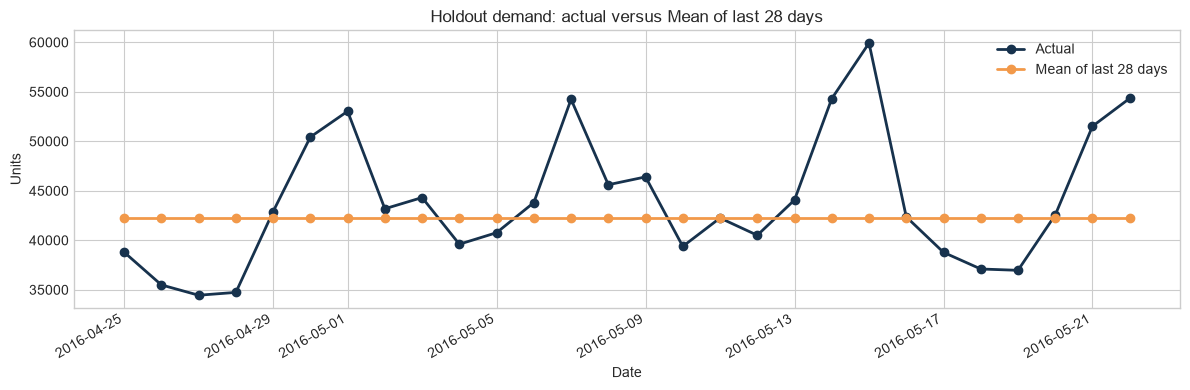

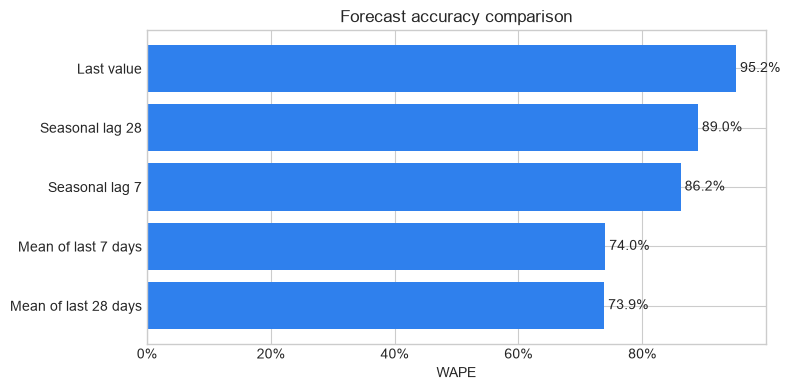

In [6]:
best_name = results.iloc[0].model
best = forecasts[best_name]
dates = calendar_days.loc[TRAIN_END:, 'date'].reset_index(drop=True)
forecast_daily = pd.DataFrame({'date': dates, 'actual': actual.sum(axis=0), 'forecast': best.sum(axis=0)})

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(forecast_daily.date, forecast_daily.actual, marker='o', linewidth=2, label='Actual', color=COLORS['navy'])
ax.plot(forecast_daily.date, forecast_daily.forecast, marker='o', linewidth=2, label=best_name, color=COLORS['orange'])
ax.set(title=f'Holdout demand: actual versus {best_name}', xlabel='Date', ylabel='Units')
ax.legend(frameon=False)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

ordered = results.sort_values('WAPE', ascending=True)
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(ordered.model, ordered.WAPE, color=COLORS['blue'])
ax.set(title='Forecast accuracy comparison', xlabel='WAPE', ylabel='')
ax.xaxis.set_major_formatter(PercentFormatter(1))
for bar, value in zip(bars, ordered.WAPE):
    ax.text(value, bar.get_y() + bar.get_height() / 2, f' {value:.1%}', va='center')
fig.tight_layout()
plt.show()


## 5. Diagnose performance by store

,store_id,actual_units,forecast_units,WAPE
2,CA_3,"175,360","176,972",67.9%
8,WI_2,"153,976","151,060",69.7%
6,TX_3,"116,610","106,422",73.0%
5,TX_2,"115,258","110,106",73.2%
9,WI_3,"114,775","111,810",73.9%
0,CA_1,"134,032","127,955",74.8%
1,CA_2,"132,920","125,031",75.2%
7,WI_1,"112,444","107,281",76.0%
4,TX_1,"97,531","92,776",76.9%
3,CA_4,"78,858","74,213",86.8%


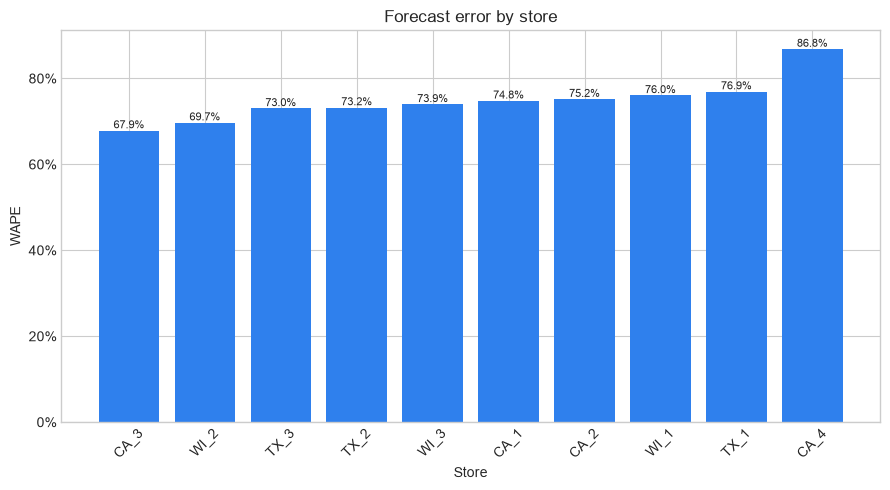

In [7]:
store_rows = []
for store in sorted(sales.store_id.unique()):
    mask = sales.store_id.eq(store).to_numpy()
    store_rows.append({
        'store_id': store,
        'actual_units': float(actual[mask].sum()),
        'forecast_units': float(best[mask].sum()),
        'WAPE': float(np.abs(actual[mask] - best[mask]).sum() / actual[mask].sum()),
    })
store_results = pd.DataFrame(store_rows).sort_values('WAPE')
display(store_results.style.format({'actual_units': '{:,.0f}', 'forecast_units': '{:,.0f}', 'WAPE': '{:.1%}'}))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(store_results.store_id, store_results.WAPE, color=COLORS['blue'])
ax.set(title='Forecast error by store', xlabel='Store', ylabel='WAPE')
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.tick_params(axis='x', rotation=45)
for bar, value in zip(bars, store_results.WAPE):
    ax.text(bar.get_x() + bar.get_width()/2, value, f'{value:.1%}', ha='center', va='bottom', fontsize=8)
fig.tight_layout()
plt.show()


## Conclusion
The strongest simple method becomes the benchmark that every machine-learning model must beat on the same untouched 28-day horizon.